# Decision Tree

In [118]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [119]:
df = pd.read_csv("../data/drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [120]:
df.shape

(200, 6)

In [121]:
X = df.drop(["Drug"], axis=1).values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [122]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

In [123]:
# from sklearn.preprocessing import LabelEncoder

# le_sex = LabelEncoder()
# le_sex.fit(['F','M'])
# X[:,1] = le_sex.transform(X[:,1])

# le_BP = LabelEncoder()
# le_BP.fit(['LOW','NORMAL','HIGH'])
# X[:,2] = le_BP.transform(X[:,2])

# le_cho = LabelEncoder()
# le_cho.fit(['NORMAL','HIGH'])
# X[:,3] = le_cho.transform(X[:,3])

from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
X[:,1] = le_sex.fit_transform(X[:,1])

le_BP = LabelEncoder()
X[:,2] = le_BP.fit_transform(X[:,2])

le_cho = LabelEncoder()
X[:,3] = le_cho.fit_transform(X[:,3])

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

In [125]:
print(X_train.shape)
print(y_train.shape)

(140, 5)
(140,)


In [126]:
print(X_test.shape)
print(y_test.shape)

(60, 5)
(60,)


In [127]:
drugTree = DecisionTreeClassifier(criterion='entropy', max_depth=4)
drugTree

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [128]:
drugTree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [129]:
y_hat = drugTree.predict(X_test)
print(y_test[0:5].values)
print(y_hat[0:5])

['drugY' 'drugX' 'drugX' 'drugX' 'drugX']
['drugY' 'drugX' 'drugX' 'drugX' 'drugX']


In [130]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_hat))

0.9833333333333333


In [131]:
from io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
import matplotlib.pyplot as plt

(-0.5, 1034.5, 735.5, -0.5)

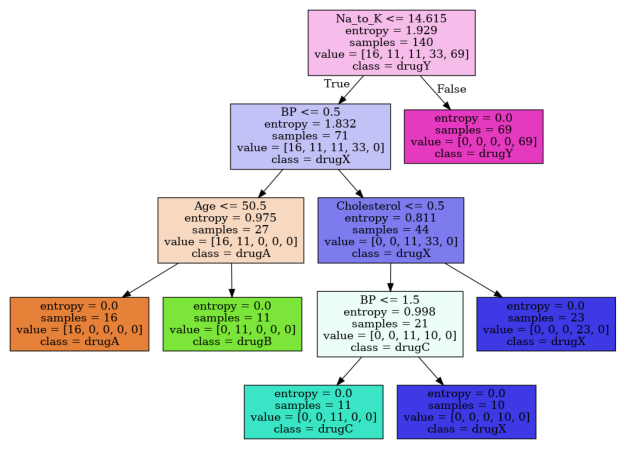

In [132]:
dot_data = StringIO()
file_name = "drugtree.png"

featureNames = list(df.columns[0:5])

tree.export_graphviz(
    drugTree,
    feature_names=featureNames,
    class_names=drugTree.classes_,
    filled=True,
    out_file=dot_data
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png(file_name)

img = mpimg.imread(file_name)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis('off')
